# 02 - Least-Squares Baseline

Goal: corrupt the clean simulated trajectory with realistic sensor noise and missingness, then try to recover the physical parameters `(c, k)` via nonlinear least-squares. This is the naive baseline that motivates the Bayesian approach in notebook 03 -- watch for where it starts to break down as noise increases.

In [1]:
import sys
sys.path.insert(0, '../src')

import numpy as np
import matplotlib.pyplot as plt

from simulate import OscillatorParams, simulate
from noise import NoiseConfig, corrupt_trajectory
from fit_leastsquares import fit_leastsquares
from run_noise_experiment import run_experiment

## Ground truth system

Same system as notebook 01: an underdamped oscillator with known `m, c, k`. In practice we only ever have `m=1` fixed, since (as noted in `fit_leastsquares.py`) position data alone can't uniquely identify absolute mass -- only the ratios `c/m` and `k/m` affect the dynamics.

In [2]:
true_params = OscillatorParams(m=1.0, c=0.3, k=4.0)
x0, v0 = 1.0, 0.0
t, x_clean, v_clean = simulate(true_params, x0, v0, t_span=(0, 20), n_points=300)
print(f'true c={true_params.c}, true k={true_params.k}')

true c=0.3, true k=4.0


## Corrupt the trajectory

Add Gaussian measurement noise and simulate 5% sensor dropout.

In [3]:
config = NoiseConfig(sigma=0.1, missing_frac=0.05, seed=42)
t_obs, x_obs = corrupt_trajectory(t, x_clean, config)
print(f'observed {len(t_obs)} of {len(t)} original samples')

observed 283 of 300 original samples


## Fit (c, k) via least-squares

In [4]:
c_hat, k_hat, result = fit_leastsquares(t_obs, x_obs, x0, v0)
print(f'recovered c = {c_hat:.4f} (true: {true_params.c})')
print(f'recovered k = {k_hat:.4f} (true: {true_params.k})')
print(f'converged: {result.success}')

recovered c = 0.3009 (true: 0.3)
recovered k = 4.0221 (true: 4.0)
converged: True


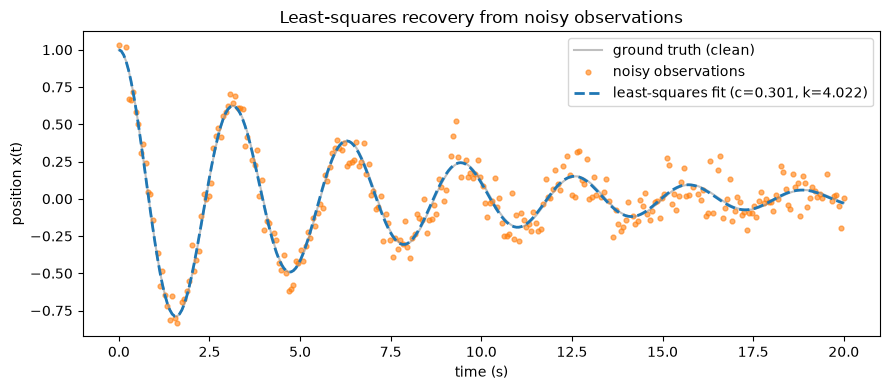

In [5]:
fitted_params = OscillatorParams(m=1.0, c=c_hat, k=k_hat)
_, x_fit, _ = simulate(fitted_params, x0, v0, t_span=(0, 20), n_points=300)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(t, x_clean, label='ground truth (clean)', color='gray', alpha=0.5, linewidth=1.5)
ax.scatter(t_obs, x_obs, label='noisy observations', color='C1', s=12, alpha=0.6)
ax.plot(t, x_fit, label=f'least-squares fit (c={c_hat:.3f}, k={k_hat:.3f})', color='C0', linewidth=2, linestyle='--')
ax.set_xlabel('time (s)'); ax.set_ylabel('position x(t)')
ax.set_title('Least-squares recovery from noisy observations')
ax.legend()
plt.tight_layout()
plt.savefig('../figures/02_fit_example.png', dpi=150)
plt.show()

## The key experiment: error vs. noise level

A single fit at one noise level doesn't tell us much on its own. The real question: **how does recovery error scale as measurement noise increases?** We sweep noise levels and repeat each with multiple random seeds to get a sense of the spread, not just a single lucky (or unlucky) fit.

In [6]:
sigma_levels = [0.01, 0.05, 0.1, 0.2, 0.4]
results = run_experiment(true_params, x0, v0, (0, 20), 300, sigma_levels, n_seeds=20)

for sigma in sigma_levels:
    c_errs = results[sigma]['c_errors']
    k_errs = results[sigma]['k_errors']
    print(f'sigma={sigma:.2f}: mean|c_err|={np.mean(c_errs):.4f}, mean|k_err|={np.mean(k_errs):.4f}')

sigma=0.01: mean|c_err|=0.0007, mean|k_err|=0.0013
sigma=0.05: mean|c_err|=0.0036, mean|k_err|=0.0068
sigma=0.10: mean|c_err|=0.0073, mean|k_err|=0.0136
sigma=0.20: mean|c_err|=0.0144, mean|k_err|=0.0278
sigma=0.40: mean|c_err|=0.0279, mean|k_err|=0.0581


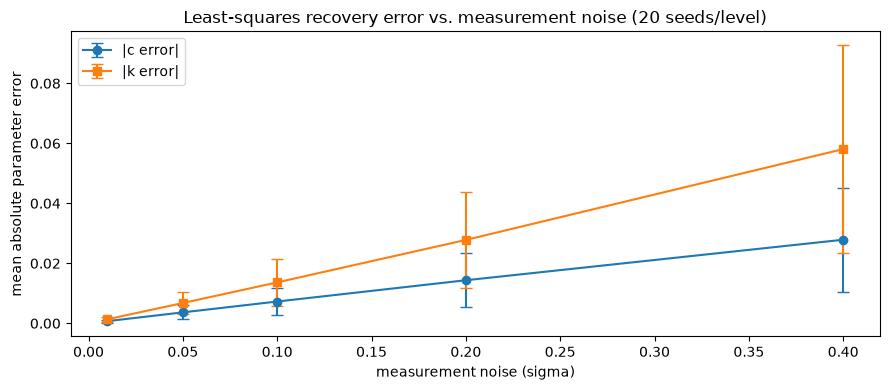

In [7]:
means_c = [np.mean(results[s]['c_errors']) for s in sigma_levels]
stds_c  = [np.std(results[s]['c_errors']) for s in sigma_levels]
means_k = [np.mean(results[s]['k_errors']) for s in sigma_levels]
stds_k  = [np.std(results[s]['k_errors']) for s in sigma_levels]

fig, ax = plt.subplots(figsize=(9, 4))
ax.errorbar(sigma_levels, means_c, yerr=stds_c, marker='o', label='|c error|', capsize=4)
ax.errorbar(sigma_levels, means_k, yerr=stds_k, marker='s', label='|k error|', capsize=4)
ax.set_xlabel('measurement noise (sigma)')
ax.set_ylabel('mean absolute parameter error')
ax.set_title('Least-squares recovery error vs. measurement noise (20 seeds/level)')
ax.legend()
plt.tight_layout()
plt.savefig('../figures/02_error_vs_noise.png', dpi=150)
plt.show()

## Takeaways

- Least-squares recovers parameters well at low noise, but error grows roughly linearly with `sigma` -- and at higher noise levels it gives no indication of *how much* to trust the point estimate.
- This is the core motivation for notebook 03: instead of a single `(c_hat, k_hat)`, we want a full posterior distribution that honestly reflects how uncertain we should be, especially as noise increases.
- Identifiability constraint: `m` was fixed at 1 throughout, since position-only observations can't separate absolute mass from the `c/m`, `k/m` ratios that actually drive the dynamics.